In [1]:
import pandas as pd
import warnings

from skbio import OrdinationResults
from joint_rpca_functions import plot_log_ratios, shared_log_ratios
from joint_rpca_output_preprocessing import (misame_meta_add_cols, vital_meta_add_cols,
                                             load_misame_raw_tables, load_vital_raw_tables,
                                             get_shared_cohort_features)

warnings.filterwarnings('ignore')
%matplotlib inline

## Data Loading

In [2]:
#dict to spell out modality names
mod_name_dict = {'micro': 'Micronutrients', 'macro': 'Macronutrients', 
                 'biocrates': 'Biocrates', 'hmo': 'HMOs',
                 'untargeted_sapient': 'Untargeted_104'}

In [3]:
#load misame raw tables
misame_tables_all = load_misame_raw_tables(dir_path='../../../Joint-RPCA/output/all_tps')

#load metadata
misame_metadata = pd.read_csv('../../../../Data/MISAME/metadata/misame_processed_metadata.tsv', sep='\t', index_col=0)
misame_metadata = misame_meta_add_cols(misame_metadata)

#load Joint-RPCA results
mis_ord_sapient = OrdinationResults.read('../../../Joint-RPCA/output/all_tps/misame_ord_with_untarg_sapient_final.txt')
mis_ord_sapient_feats = mis_ord_sapient.features.copy()
mis_ord_sapient_feats.rename(columns={0:'PC1', 1:'PC2', 2:'PC3'}, inplace=True)

#load misame feature loadings
misame_rankings = {}
for mod in mod_name_dict.keys():
    misame_rankings[mod] = pd.read_excel("../../../Joint-RPCA/output/misame_feature_loadings_final.xlsx", 
                                         sheet_name=f"{mod_name_dict[mod]}", index_col=0)

In [4]:
#load vital (Mumta-LW) raw data
vital_tables_all = load_vital_raw_tables(dir_path='../../../Joint-RPCA/output/all_tps')
#harmonize macro labels
macro_harmonize = {"CHO":"CARBOHYDRATE", "Fat":"FAT", 
                   'kcal/L':"Kcal.L", "Protein":"PROTEIN"}
vital_tables_all['macro'].columns = vital_tables_all['macro'].columns.map(macro_harmonize)

#load metadata
vital_metadata = pd.read_csv('../../../../Data/VITAL/metadata/vital_processed_metadata.tsv', sep='\t', index_col=0)
vital_metadata = vital_meta_add_cols(vital_metadata)

#load Joint-RPCA results
vit_ord_sapient = OrdinationResults.read('../../../Joint-RPCA/output/all_tps/vital_ord_with_untarg_sapient_v3.txt')
vit_ord_sapient_feats = vit_ord_sapient.features.copy()
vit_ord_sapient_feats.rename(columns={0:'PC1', 1:'PC2', 2:'PC3'}, inplace=True)

#load vital feature loadings
vital_rankings = {}
for mod in mod_name_dict.keys():
    vital_rankings[mod] = pd.read_excel("../../../Joint-RPCA/output/vital_feature_loadings_final.xlsx", 
                                        sheet_name=f"{mod_name_dict[mod]}", index_col=0)
vital_rankings['macro'].index = vital_rankings['macro'].index.map(macro_harmonize)

## Plotting

In [5]:
#get shared numerator and denominator features across cohorts
shared_num, shared_denom = get_shared_cohort_features(mod_list=mod_name_dict.keys(),
                                                      misame_rankings=misame_rankings, 
                                                      vital_rankings=vital_rankings)

misame_logs = shared_log_ratios(misame_tables_all, shared_num, shared_denom)
vital_logs = shared_log_ratios(vital_tables_all, shared_num, shared_denom)

### MISAME

micro
Timepoint: 1 pvalue: 0.0
Timepoint: 2 pvalue: 0.0
Timepoint: 3 pvalue: 0.0
hmo
Timepoint: 1 pvalue: 0.0239
Timepoint: 2 pvalue: 0.1093
Timepoint: 3 pvalue: 0.0191
biocrates
Timepoint: 1 pvalue: 0.2261
Timepoint: 2 pvalue: 0.6646
Timepoint: 3 pvalue: 0.2265
untargeted_sapient
Timepoint: 1 pvalue: 0.0
Timepoint: 2 pvalue: 0.0
Timepoint: 3 pvalue: 0.0


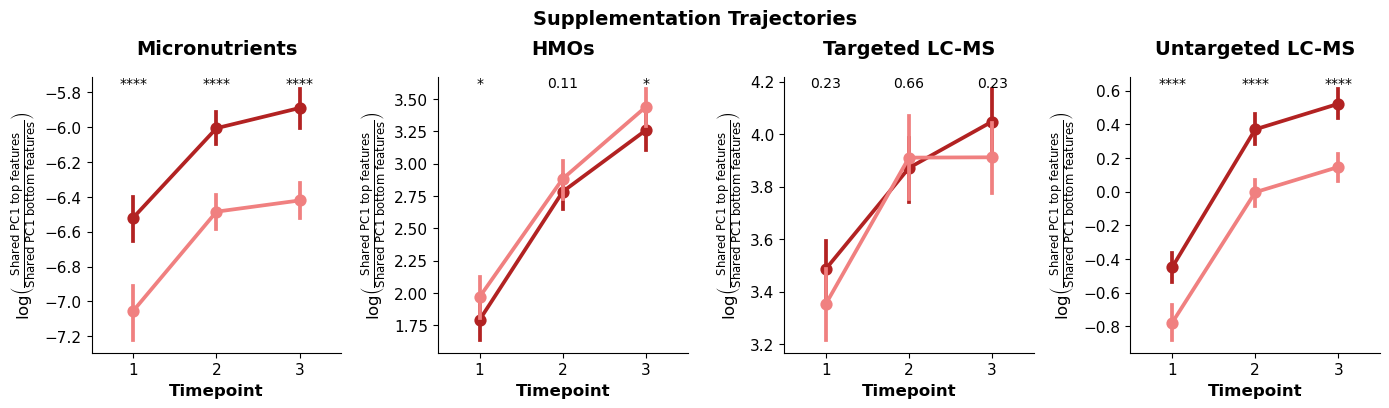

In [6]:
plot_log_ratios(misame_logs, misame_metadata, phenotype='BEP_pub', timepoint='Timepoint', shared_set=True,
                modality_lst = ['micro', 'hmo', 'biocrates', 'untargeted_sapient'], axis_use='PC1', hue_order = ['Yes','No'],
                legend_labels = None, legend_title = 'BEP', legend_loc='lower right', palette=["firebrick", "lightcoral"],
                plot_subtitle = 'Supplementation Trajectories', savefig=False, make_legend=False,
                save_path='../../../../Figures/Joint-RPCA/Figure5/MISAME_BEP_trajectories_PC1_shared-set.pdf')

micro
Timepoint: 1 pvalue: 0.0567
Timepoint: 2 pvalue: 0.4717
Timepoint: 3 pvalue: 0.4681
hmo
Timepoint: 1 pvalue: 0.0865
Timepoint: 2 pvalue: 0.0505
Timepoint: 3 pvalue: 0.1825
biocrates
Timepoint: 1 pvalue: 0.1501
Timepoint: 2 pvalue: 0.3151
Timepoint: 3 pvalue: 0.5209
untargeted_sapient
Timepoint: 1 pvalue: 0.0
Timepoint: 2 pvalue: 0.1732
Timepoint: 3 pvalue: 0.0019


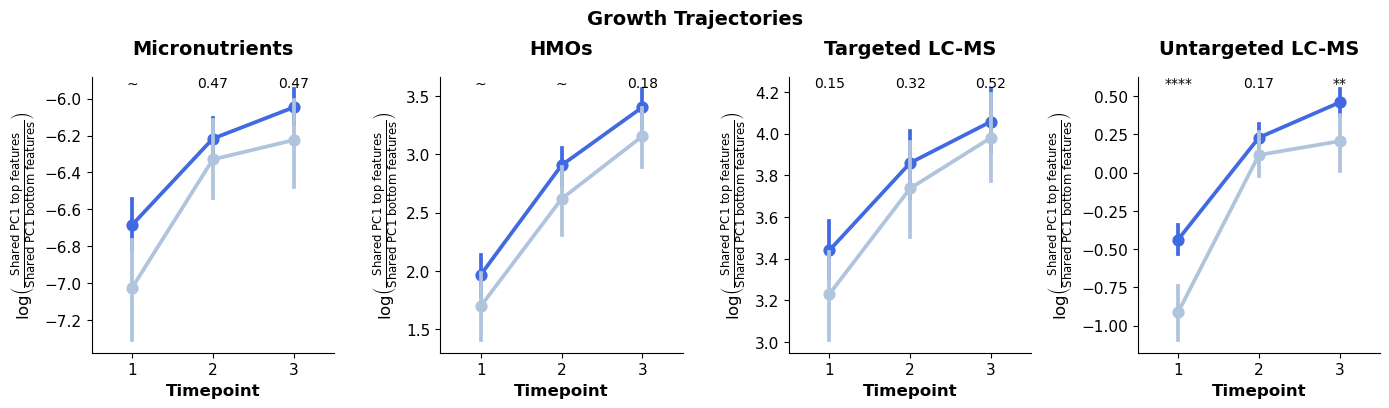

In [7]:
plot_log_ratios(misame_logs, misame_metadata, phenotype='WAZ_M04_wide_margin', timepoint='Timepoint', shared_set=True,
                modality_lst = ['micro', 'hmo', 'biocrates', 'untargeted_sapient'], hue_order=[0.0, 1.0],
                legend_labels = {'1.0':'<-1', '0.0':'>0'}, legend_title = 'WAZ M04', legend_loc='lower right',
                plot_subtitle = 'Growth Trajectories', axis_use='PC1', make_legend=False, palette=['royalblue','lightsteelblue'],
                savefig=False, save_path='../../../../Figures/Joint-RPCA/Figure5/MISAME_WAZ-M04_trajectories_PC1_shared-set.pdf')

### Mumta-LW

micro
Timepoint: 1 pvalue: 0.0
Timepoint: 2 pvalue: 0.0
hmo
Timepoint: 1 pvalue: 0.0501
Timepoint: 2 pvalue: 0.1015
biocrates
Timepoint: 1 pvalue: 0.0
Timepoint: 2 pvalue: 0.2863
untargeted_sapient
Timepoint: 1 pvalue: 0.0
Timepoint: 2 pvalue: 0.0118


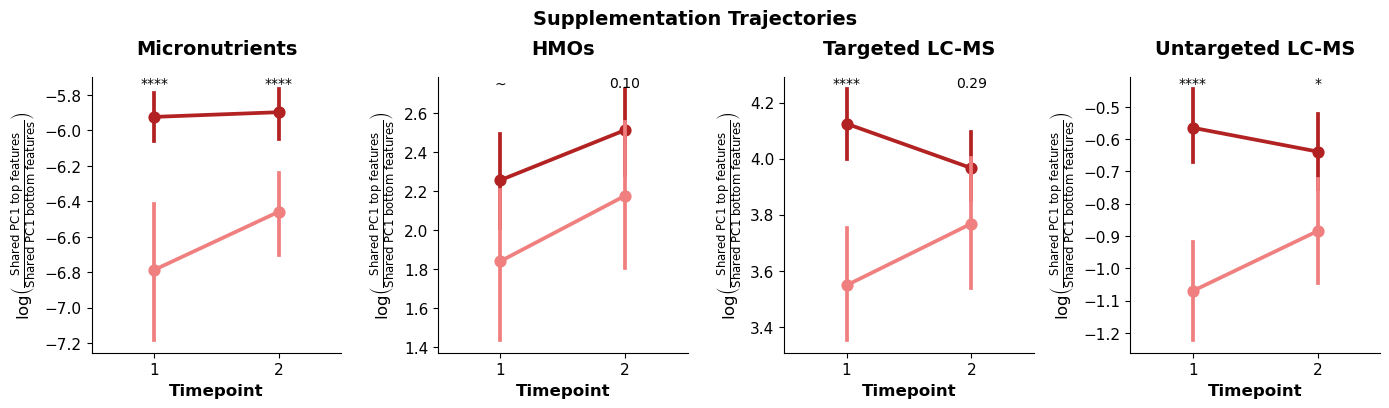

In [8]:
plot_log_ratios(vital_logs, vital_metadata, phenotype = 'BEP_pub', timepoint = 'Timepoint', shared_set=True,
                modality_lst = ['micro', 'hmo', 'biocrates', 'untargeted_sapient'], axis_use='PC1',
                legend_labels = None, legend_title = 'BEP', legend_loc='lower right', hue_order = ['Yes','No'],
                plot_subtitle = 'Supplementation Trajectories', make_legend = False, palette = ['firebrick', 'lightcoral'],
                savefig=False, save_path='../../../../Figures/Joint-RPCA/Figure5/VITAL_BEP_trajectories_PC1_shared-set.pdf')

micro
Timepoint: 1 pvalue: 0.0025
Timepoint: 2 pvalue: 0.0116
hmo
Timepoint: 1 pvalue: 0.1192
Timepoint: 2 pvalue: 0.3673
biocrates
Timepoint: 1 pvalue: 0.0071
Timepoint: 2 pvalue: 0.1917
untargeted_sapient
Timepoint: 1 pvalue: 0.0002
Timepoint: 2 pvalue: 0.0095


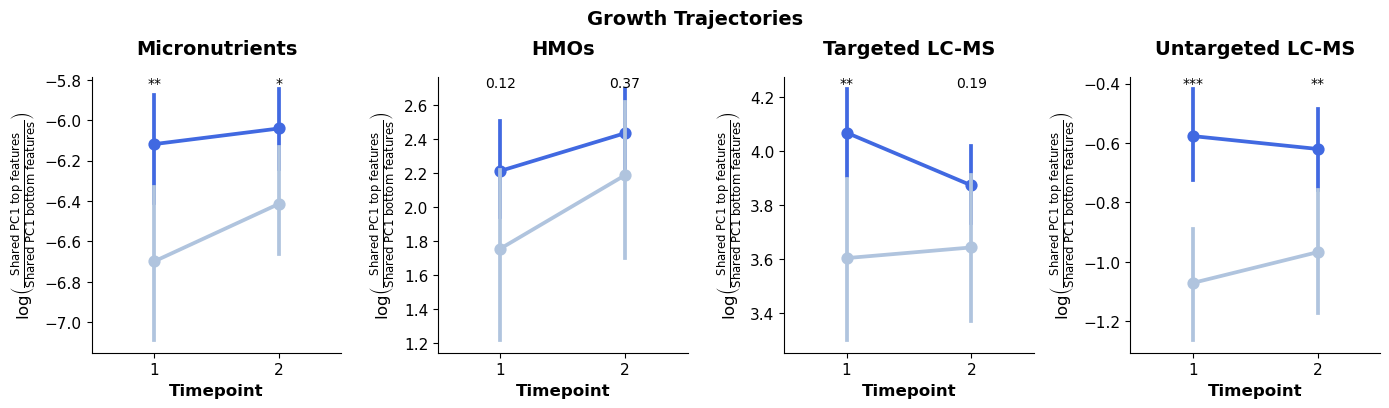

In [9]:
plot_log_ratios(vital_logs, vital_metadata, phenotype='WAZ_M04_wide_margin', timepoint='Timepoint', shared_set=True,
                modality_lst = ['micro', 'hmo', 'biocrates', 'untargeted_sapient'], hue_order=[0.0, 1.0],
                legend_labels = {'1.0':'<-2', '0.0':'>-1'}, legend_title = 'WAZ M04', legend_loc='lower right',
                plot_subtitle = 'Growth Trajectories', axis_use='PC1', make_legend=False, palette=['royalblue','lightsteelblue'],
                savefig=False, save_path='../../../../Figures/Joint-RPCA/Figure5/VITAL_WAZ-M04_trajectories_PC1_shared-set.pdf')